# 🧮 Énigmes & Merveilles de Jean-Paul Delahaye

*Un notebook démo pour matheux, dans l'esprit de Jean-Paul Delahaye — informaticien et mathématicien,
professeur émérite à l'Université de Lille, chroniqueur de la rubrique « Logique et Calcul » de
*Pour la Science* depuis 1996, auteur d'ouvrages de référence sur les nombres premiers, la complexité
algorithmique, le hasard, les jeux et les systèmes de vote.*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses chroniques
et de ses livres, dans la continuité de la démo JupyterLab entamée avec Gardner, Pickover et Stewart —
même recette : calcul, texte, visualisation et interactivité réunis dans un seul document.

**Sommaire**

1. [La suite de Syracuse (conjecture de Collatz)](#1)
2. [La fourmi de Langton](#2)
3. [Le dilemme du prisonnier itéré](#3) — tournois à la Axelrod
4. [Complexité de Kolmogorov et nombre Oméga de Chaitin](#4)
5. [Le paradoxe de Condorcet](#5) — mathématiques du vote
6. [La suite de Recamán](#6)
7. [L'ensemble de Cantor et la dimension fractale](#7)
8. [Nombres de Mersenne et test de Lucas-Lehmer](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. La suite de Syracuse (conjecture de Collatz) <a id="1"></a>

Delahaye revient régulièrement sur cette conjecture dans "Logique et Calcul" tant elle illustre à
merveille son thème de prédilection : des règles d'une simplicité enfantine engendrant un comportement
totalement imprévisible. La règle : si $n$ est pair, diviser par 2 ; si $n$ est impair, calculer $3n+1$.
Conjecture (toujours ouverte) : on retombe toujours sur 1, quel que soit le nombre de départ.

Exemple emblématique : $n=27$ met 111 étapes à redescendre à 1, en grimpant jusqu'à 9232 au passage —
un excellent contre-exemple à l'intuition qui voudrait qu'un petit nombre de départ donne un trajet court.

n=27 : 111 étapes, valeur maximale atteinte = 9232


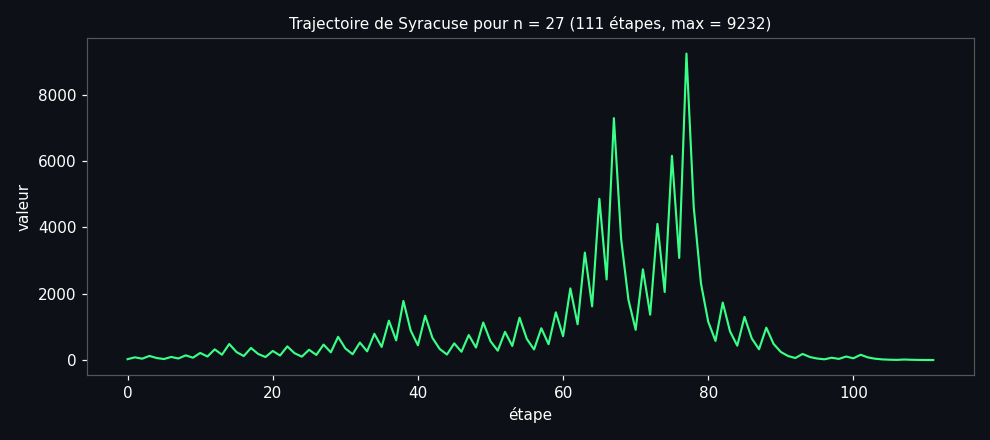

In [1]:
import matplotlib.pyplot as plt

def collatz_traj(n):
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq

seq = collatz_traj(27)
print(f"n=27 : {len(seq)-1} étapes, valeur maximale atteinte = {max(seq)}")

fig, ax = plt.subplots(figsize=(9, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(seq, color="#39ff88", lw=1.4)
ax.set_xlabel("étape", color="white")
ax.set_ylabel("valeur", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Trajectoire de Syracuse pour n = 27 (111 étapes, max = 9232)", color="white", fontsize=10)
plt.show()

Delahaye aime aussi étudier la statistique du "temps de vol" sur de grandes plages de nombres, pour
chasser d'éventuels records ou motifs cachés — sans jamais rien y trouver qui trahisse un contre-exemple.

Record local sur cet intervalle : n=6171 avec 261 étapes


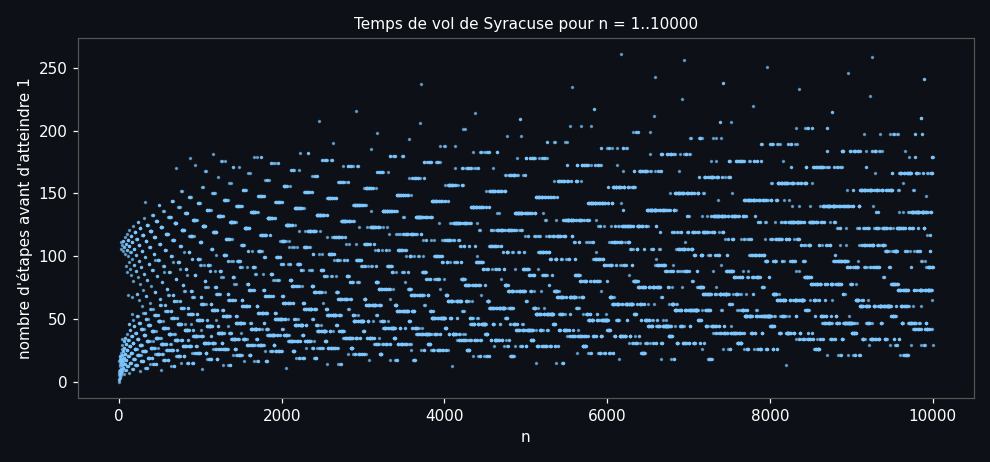

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def collatz_steps(n):
    steps = 0
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        steps += 1
    return steps

N = 10000
lengths = np.array([collatz_steps(n) for n in range(1, N+1)])

fig, ax = plt.subplots(figsize=(9, 4.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.scatter(range(1, N+1), lengths, s=1.5, color="#7ec8ff", alpha=0.6)
ax.set_xlabel("n", color="white")
ax.set_ylabel("nombre d'étapes avant d'atteindre 1", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title(f"Temps de vol de Syracuse pour n = 1..{N}", color="white", fontsize=10)
plt.show()

print(f"Record local sur cet intervalle : n={int(np.argmax(lengths))+1} avec {int(lengths.max())} étapes")

## 2. La fourmi de Langton <a id="2"></a>

Automate cellulaire à deux règles ultra-simples (introduit par Chris Langton en 1986) que Delahaye a
souvent utilisé comme exemple canonique d'émergence : sur case blanche, tourne à droite et noircit la
case ; sur case noire, tourne à gauche et blanchit la case ; puis avance d'une case. Après une phase
chaotique d'environ 10 000 pas, une structure périodique inattendue apparaît spontanément : "l'autoroute"
— la fourmi se met à construire indéfiniment un motif diagonal répétitif. Delahaye y voit un cas d'école
pour son thème central : l'ordre peut surgir du chaos sans qu'aucune règle ne le prescrive explicitement.

Après 11000 pas, la fourmi est en (96,144) ; 834 cases noircies
L'« autoroute » diagonale émerge généralement après ~10000 pas de chaos apparent.


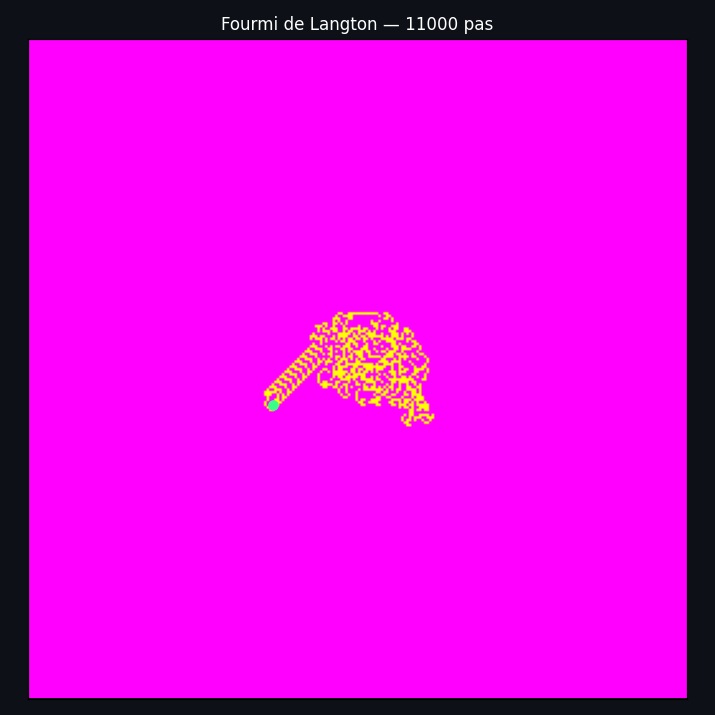

In [3]:
import numpy as np
import matplotlib.pyplot as plt

size = 260
grid = np.zeros((size, size), dtype=int)
x, y = size // 2, size // 2
directions = [(0, -1), (1, 0), (0, 1), (-1, 0)]  # haut, droite, bas, gauche
d = 0
STEPS = 11000

for _ in range(STEPS):
    if grid[y, x] == 0:
        d = (d + 1) % 4       # case blanche : tourne à droite (90° horaire)
        grid[y, x] = 1
    else:
        d = (d - 1) % 4       # case noire : tourne à gauche (90° anti-horaire)
        grid[y, x] = 0
    dx, dy = directions[d]
    x, y = x + dx, y + dy

print(f"Après {STEPS} pas, la fourmi est en ({x},{y}) ; {int(grid.sum())} cases noircies")
print("L'« autoroute » diagonale émerge généralement après ~10000 pas de chaos apparent.")

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.imshow(grid, cmap="spring", vmin=0, vmax=1)
ax.plot(x, y, marker="o", color="#39ff88", markersize=6)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Fourmi de Langton — {STEPS} pas", color="white", fontsize=11)
plt.show()

## 3. Le dilemme du prisonnier itéré <a id="3"></a>

Delahaye a consacré de nombreuses chroniques (et une partie de *Jeux mathématiques et mathématiques des
jeux*) aux tournois de Robert Axelrod (1980) : des programmes s'affrontent au dilemme du prisonnier répété,
et c'est la stratégie **Donnant-Donnant** (*Tit for Tat* : coopérer au premier coup, puis rejouer le
dernier coup de l'adversaire) qui l'emporte le plus souvent — simple, indulgente, mais jamais la première
à trahir. Ci-dessous, un mini-tournoi round-robin entre cinq stratégies classiques.

Rancunier            : score moyen = 394.4
Donnant-Donnant      : score moyen = 362.8
Toujours trahir      : score moyen = 331.6
Toujours coopérer    : score moyen = 316.8
Aléatoire            : score moyen = 290.0


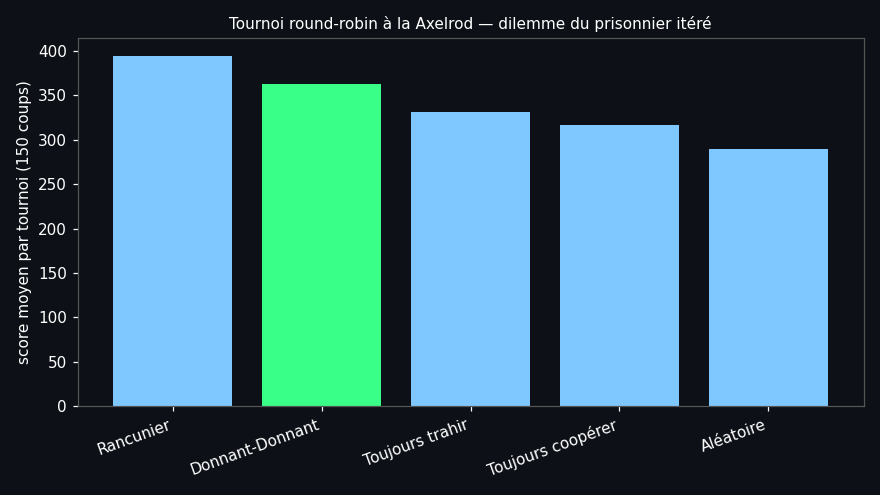

In [4]:
import matplotlib.pyplot as plt
import random
random.seed(3)

PAYOFF = {("C","C"): (3,3), ("C","D"): (0,5), ("D","C"): (5,0), ("D","D"): (1,1)}

def tit_for_tat(my_hist, opp_hist):
    return "C" if not opp_hist else opp_hist[-1]

def always_cooperate(my_hist, opp_hist):
    return "C"

def always_defect(my_hist, opp_hist):
    return "D"

def random_strategy(my_hist, opp_hist):
    return random.choice("CD")

def grim_trigger(my_hist, opp_hist):
    return "D" if "D" in opp_hist else "C"

STRATEGIES = {
    "Donnant-Donnant": tit_for_tat,
    "Toujours coopérer": always_cooperate,
    "Toujours trahir": always_defect,
    "Aléatoire": random_strategy,
    "Rancunier": grim_trigger,
}

def play(strat_a, strat_b, rounds=150):
    hist_a, hist_b = [], []
    score_a = score_b = 0
    for _ in range(rounds):
        move_a = STRATEGIES[strat_a](hist_a, hist_b)
        move_b = STRATEGIES[strat_b](hist_b, hist_a)
        pa, pb = PAYOFF[(move_a, move_b)]
        score_a += pa; score_b += pb
        hist_a.append(move_a); hist_b.append(move_b)
    return score_a, score_b

names = list(STRATEGIES.keys())
totals = {n: 0 for n in names}
for a in names:
    for b in names:
        sa, sb = play(a, b)
        totals[a] += sa

avg_scores = {n: totals[n] / len(names) for n in names}
ranking = sorted(avg_scores.items(), key=lambda kv: kv[1], reverse=True)
for name, score in ranking:
    print(f"{name:20s} : score moyen = {score:.1f}")

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
labels = [n for n, _ in ranking]
values = [v for _, v in ranking]
colors = ["#39ff88" if n == "Donnant-Donnant" else "#7ec8ff" for n in labels]
ax.bar(labels, values, color=colors)
ax.set_ylabel("score moyen par tournoi (150 coups)", color="white")
ax.tick_params(colors="white")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Tournoi round-robin à la Axelrod — dilemme du prisonnier itéré", color="white", fontsize=10)
plt.show()

## 4. Complexité de Kolmogorov et nombre Oméga de Chaitin <a id="4"></a>

Thème central de son livre *Information, complexité et hasard* : la **complexité de Kolmogorov** d'une
suite de bits est la longueur du plus court programme qui la produit — une suite est dite "algorithmiquement
aléatoire" si aucun programme plus court qu'elle-même ne peut la générer. Le **nombre Oméga de Chaitin**
(la probabilité qu'un programme aléatoire s'arrête) pousse l'idée à l'extrême : il est prouvablement
incalculable, chacun de ses chiffres encodant une vérité mathématique indépendante des autres.

On ne peut pas calculer la complexité de Kolmogorov exacte (elle est elle-même non calculable), mais on
peut l'**approcher** grossièrement par un taux de compression : plus une suite se compresse bien, moins
elle est complexe.

Périodique ("10"×N)                    :  500 octets ->   14 octets compressés (ratio 0.03)
Suite de Thue-Morse                    :  500 octets ->   44 octets compressés (ratio 0.09)
Indicatrice des nombres premiers       :  500 octets ->  265 octets compressés (ratio 0.53)
Suite aléatoire (pile ou face)         :  500 octets ->  511 octets compressés (ratio 1.02)


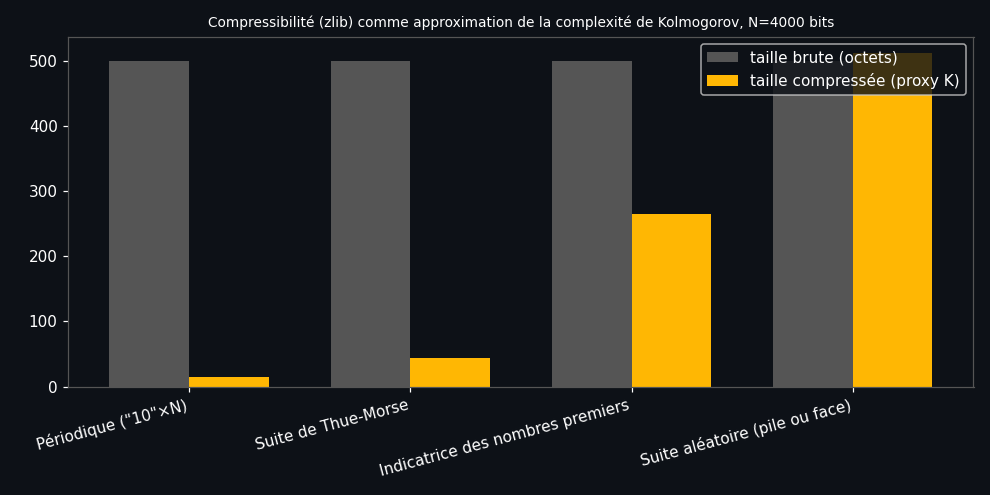

In [5]:
import matplotlib.pyplot as plt
import zlib, random
random.seed(1)

N = 4000

def thue_morse(n):
    s = "0"
    while len(s) < n:
        s += "".join("1" if c == "0" else "0" for c in s)
    return s[:n]

def prime_bits(n):
    sieve = bytearray([1]) * n
    sieve[0:2] = b"\x00\x00"
    for i in range(2, int(n**0.5)+1):
        if sieve[i]:
            sieve[i*i::i] = bytearray(len(sieve[i*i::i]))
    return "".join(str(b) for b in sieve)

strings = {
    "Périodique (\"10\"×N)":      ("10" * (N//2))[:N],
    "Suite de Thue-Morse":        thue_morse(N),
    "Indicatrice des nombres premiers": prime_bits(N),
    "Suite aléatoire (pile ou face)":   "".join(random.choice("01") for _ in range(N)),
}

results = {}
for name, s in strings.items():
    raw_bytes = int(s, 2).to_bytes((N + 7) // 8, "big")
    compressed = zlib.compress(raw_bytes, level=9)
    ratio = len(compressed) / len(raw_bytes)
    results[name] = (len(raw_bytes), len(compressed), ratio)
    print(f"{name:38s} : {len(raw_bytes):4d} octets -> {len(compressed):4d} octets compressés (ratio {ratio:.2f})")

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
names = list(results.keys())
raws = [results[n][0] for n in names]
comps = [results[n][1] for n in names]
x = range(len(names))
ax.bar([i-0.18 for i in x], raws, width=0.36, color="#555", label="taille brute (octets)")
ax.bar([i+0.18 for i in x], comps, width=0.36, color="#ffb703", label="taille compressée (proxy K)")
ax.set_xticks(list(x)); ax.set_xticklabels(names, rotation=15, ha="right", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.legend(facecolor="#0d1117", labelcolor="white")
ax.set_title(f"Compressibilité (zlib) comme approximation de la complexité de Kolmogorov, N={N} bits", color="white", fontsize=9)
plt.show()

## 5. Le paradoxe de Condorcet <a id="5"></a>

Les mathématiques du vote sont un des grands sujets de Delahaye (méthode de Borda, jugement majoritaire,
vote par approbation...). Le paradoxe mis au jour par Condorcet en 1785 : même si chaque électeur classe
les candidats de façon parfaitement cohérente (transitive), la préférence **collective** issue du vote
majoritaire par paires peut former un **cycle** — A bat B, B bat C, mais C bat A. Aucune méthode de
"vainqueur de Condorcet" ne peut alors désigner de gagnant naturel, ce qui alimente le débat sur le
meilleur système électoral.

A vs B : 67 contre 33  ->  A gagne
B vs C : 68 contre 32  ->  B gagne
C vs A : 65 contre 35  ->  C gagne

Résultat : A bat B, B bat C, C bat A — un cycle. Aucun candidat ne domine tous les autres,
alors que chaque électeur a des préférences parfaitement cohérentes (transitives).


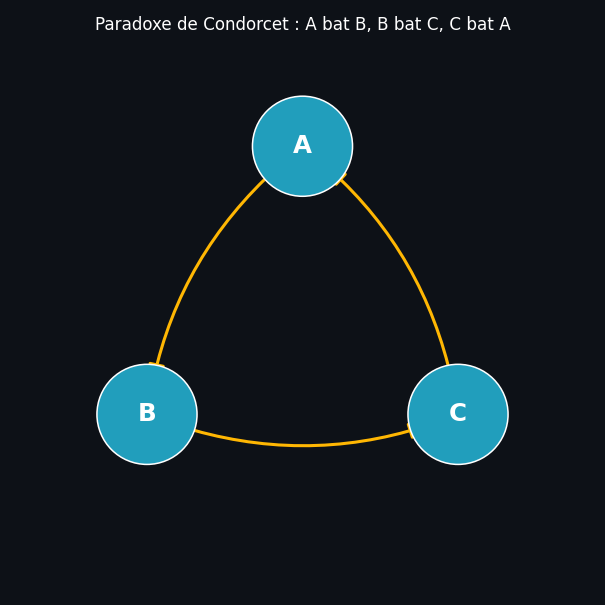

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

# Trois groupes de votants aux préférences cycliques
groups = [
    (35, ["A", "B", "C"]),
    (33, ["B", "C", "A"]),
    (32, ["C", "A", "B"]),
]

def pairwise(x, y):
    votes_x = sum(w for w, order in groups if order.index(x) < order.index(y))
    votes_y = sum(w for w, order in groups if order.index(y) < order.index(x))
    return votes_x, votes_y

for x, y in [("A","B"), ("B","C"), ("C","A")]:
    vx, vy = pairwise(x, y)
    winner = x if vx > vy else y
    print(f"{x} vs {y} : {vx} contre {vy}  ->  {winner} gagne")

print()
print("Résultat : A bat B, B bat C, C bat A — un cycle. Aucun candidat ne domine tous les autres,")
print("alors que chaque électeur a des préférences parfaitement cohérentes (transitives).")

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
pos = {"A": (0, 1), "B": (-0.87, -0.5), "C": (0.87, -0.5)}
for name, (px, py) in pos.items():
    ax.add_patch(Circle((px, py), 0.28, facecolor="#219ebc", edgecolor="white", zorder=3))
    ax.text(px, py, name, ha="center", va="center", color="white", fontsize=16, fontweight="bold", zorder=4)

edges = [("A","B"), ("B","C"), ("C","A")]
for a, b in edges:
    xa, ya = pos[a]; xb, yb = pos[b]
    arrow = FancyArrowPatch((xa, ya), (xb, yb), connectionstyle="arc3,rad=0.2",
                             arrowstyle="-|>", mutation_scale=22, color="#ffb703",
                             shrinkA=22, shrinkB=22, linewidth=2, zorder=2)
    ax.add_patch(arrow)

ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.4, 1.6)
ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Paradoxe de Condorcet : A bat B, B bat C, C bat A", color="white", fontsize=11)
plt.show()

## 6. La suite de Recamán <a id="6"></a>

Suite ludique (OEIS A005132) que Delahaye a présentée dans ses chroniques pour son mélange d'esthétique
et de simplicité : $a(0)=0$, puis $a(n) = a(n-1) - n$ si ce nombre est strictement positif et pas encore
apparu dans la suite, sinon $a(n) = a(n-1) + n$. Le résultat, tracé sous forme de demi-cercles alternés,
donne la spirale caractéristique bien connue des amateurs de mathématiques récréatives.

Premiers termes : [0, 1, 3, 6, 2, 7, 13, 20, 12, 21, 11, 22, 10, 23, 9]


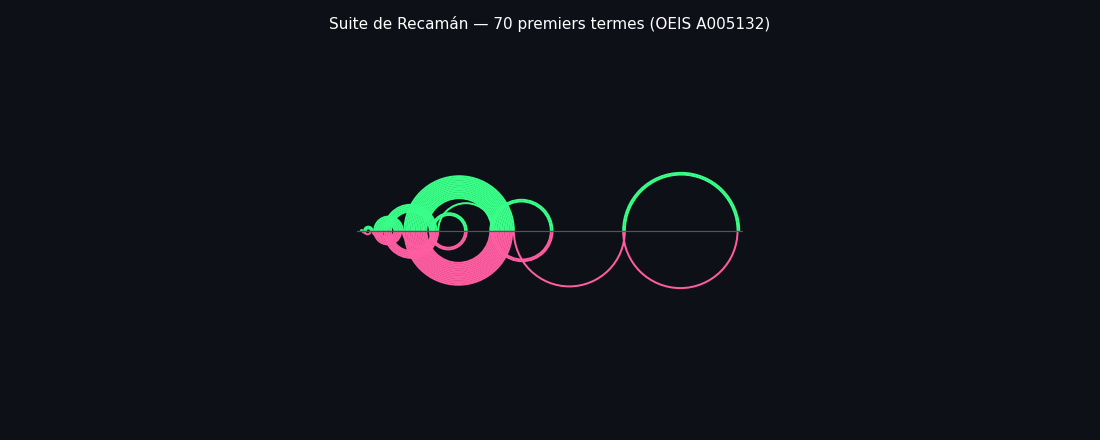

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def recaman(n_terms):
    seq = [0]
    seen = {0}
    for n in range(1, n_terms):
        prev = seq[-1]
        candidate = prev - n
        if candidate > 0 and candidate not in seen:
            seq.append(candidate)
        else:
            seq.append(prev + n)
        seen.add(seq[-1])
    return seq

seq = recaman(70)
print("Premiers termes :", seq[:15])

fig, ax = plt.subplots(figsize=(10, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for i in range(len(seq) - 1):
    a, b = seq[i], seq[i+1]
    center = (a + b) / 2
    radius = abs(b - a) / 2
    above = (i % 2 == 0)
    theta1, theta2 = (0, 180) if above else (180, 360)
    color = "#39ff88" if above else "#ff5da2"
    arc = Arc((center, 0), 2*radius, 2*radius, theta1=theta1, theta2=theta2, color=color, lw=1.3)
    ax.add_patch(arc)

ax.set_xlim(-2, max(seq)+2)
ax.set_ylim(-max(seq)/2 - 2, max(seq)/2 + 2)
ax.axhline(0, color="#555", lw=0.8)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Suite de Recamán — 70 premiers termes (OEIS A005132)", color="white", fontsize=10)
plt.show()

## 7. L'ensemble de Cantor et la dimension fractale <a id="7"></a>

Delahaye a consacré plusieurs numéros de *Pour la Science* aux objets fractals et à la notion de
**dimension non entière**. L'ensemble triadique de Cantor se construit en retirant indéfiniment le tiers
central de chaque segment restant. À chaque itération, le nombre de segments double tandis que leur
longueur totale tend vers 0 — l'ensemble limite a une "dimension de Hausdorff" $\ln 2/\ln 3 \approx 0{,}631$,
strictement comprise entre celle d'un point (0) et celle d'un segment (1).

Nombre de segments à l'itération 7 : 128 (= 2^7)
Longueur totale restante : 0.05853  (tend vers 0)
Dimension fractale (Hausdorff) : ln(2)/ln(3) ≈ 0.63093  — non entière, entre 0 (point) et 1 (segment)


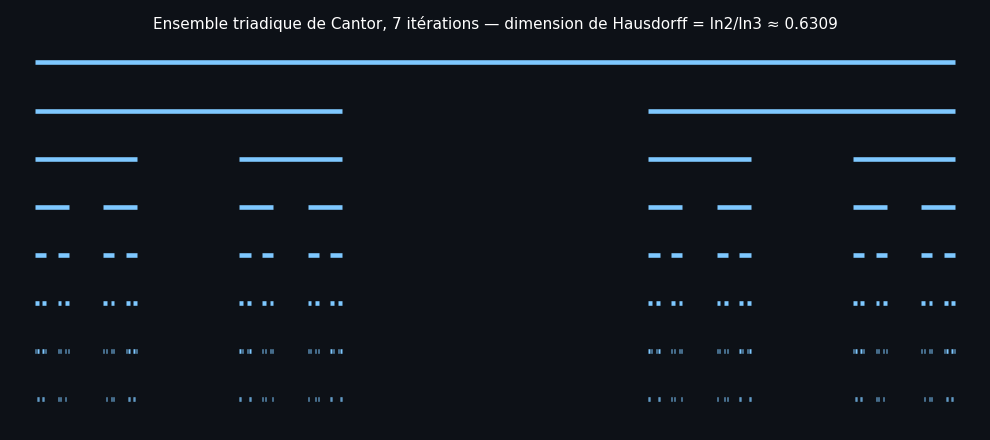

In [8]:
import matplotlib.pyplot as plt
import math

def cantor_levels(iterations):
    segments = [(0.0, 1.0)]
    levels = [segments]
    for _ in range(iterations):
        new_segments = []
        for a, b in segments:
            third = (b - a) / 3
            new_segments.append((a, a + third))
            new_segments.append((b - third, b))
        segments = new_segments
        levels.append(segments)
    return levels

ITER = 7
levels = cantor_levels(ITER)

fig, ax = plt.subplots(figsize=(9, 4), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for i, segs in enumerate(levels):
    y = ITER - i
    for a, b in segs:
        ax.plot([a, b], [y, y], color="#7ec8ff", lw=3, solid_capstyle="butt")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.5, ITER + 0.5)
ax.set_axis_off()
dim = math.log(2) / math.log(3)
ax.set_title(f"Ensemble triadique de Cantor, {ITER} itérations — dimension de Hausdorff = ln2/ln3 ≈ {dim:.4f}",
             color="white", fontsize=10)
plt.show()

print(f"Nombre de segments à l'itération {ITER} : {len(levels[-1])} (= 2^{ITER})")
print(f"Longueur totale restante : {(2/3)**ITER:.5f}  (tend vers 0)")
print(f"Dimension fractale (Hausdorff) : ln(2)/ln(3) ≈ {dim:.5f}  — non entière, entre 0 (point) et 1 (segment)")

## 8. Nombres de Mersenne et test de Lucas-Lehmer <a id="8"></a>

Delahaye chronique régulièrement les records de "plus grand nombre premier connu", presque toujours des
**nombres de Mersenne** ($2^p - 1$), traqués par le projet collaboratif GIMPS. Le **test de Lucas-Lehmer**
permet de vérifier la primalité de $2^p-1$ très efficacement : on itère $s \leftarrow s^2 - 2 \pmod{2^p-1}$
en partant de $s=4$ ; $2^p-1$ est premier si et seulement si, après $p-2$ itérations, $s \equiv 0$.

Exposants premiers testés (2 à 130) : 31
Exposants p pour lesquels 2^p - 1 est premier (nombre de Mersenne) : [2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127]


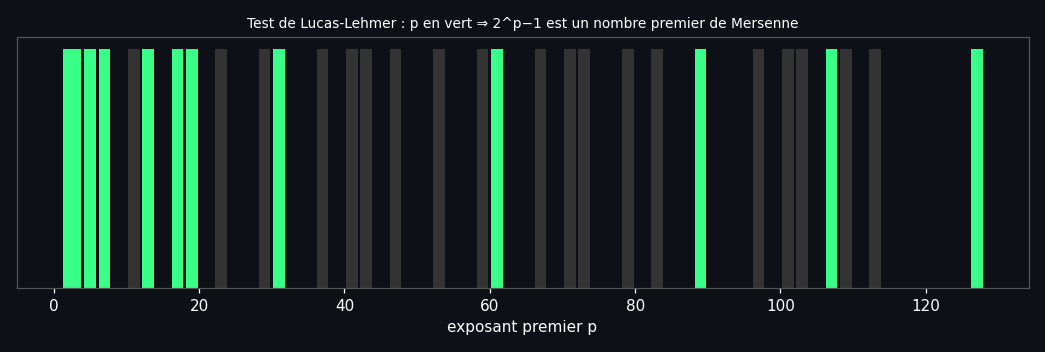

In [9]:
import matplotlib.pyplot as plt

def is_prime(k):
    if k < 2: return False
    if k in (2,3): return True
    if k % 2 == 0: return False
    i = 3
    while i*i <= k:
        if k % i == 0: return False
        i += 2
    return True

def lucas_lehmer(p):
    if p == 2:
        return True
    M = (1 << p) - 1
    s = 4
    for _ in range(p - 2):
        s = (s*s - 2) % M
    return s == 0

exponents = [p for p in range(2, 130) if is_prime(p)]
mersenne_prime = [p for p in exponents if lucas_lehmer(p)]
print(f"Exposants premiers testés (2 à 130) : {len(exponents)}")
print("Exposants p pour lesquels 2^p - 1 est premier (nombre de Mersenne) :", mersenne_prime)

fig, ax = plt.subplots(figsize=(9.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
colors = ["#39ff88" if lucas_lehmer(p) else "#333" for p in exponents]
ax.bar(exponents, [1]*len(exponents), color=colors, width=1.6)
ax.set_yticks([])
ax.set_xlabel("exposant premier p", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Test de Lucas-Lehmer : p en vert ⇒ 2^p−1 est un nombre premier de Mersenne", color="white", fontsize=9)
plt.show()

## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour rejouer la trajectoire de Syracuse pour n'importe quel
nombre de départ, et un second pour explorer la fourmi de Langton pas à pas et voir le chaos se
transformer progressivement en autoroute. Idéal pour montrer qu'un notebook Jupyter est un vrai labo
interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
import numpy as np

def collatz_traj(n):
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq

def show_syracuse(n=27):
    seq = collatz_traj(n)
    fig, ax = plt.subplots(figsize=(7, 3.5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.plot(seq, color="#39ff88", lw=1.4)
    ax.tick_params(colors="white")
    ax.set_title(f"n = {n} : {len(seq)-1} étapes, max = {max(seq)}", color="white")
    plt.show()

def show_langton(steps=2000):
    size = 260
    grid = np.zeros((size, size), dtype=int)
    x, y = size // 2, size // 2
    directions = [(0, -1), (1, 0), (0, 1), (-1, 0)]
    d = 0
    for _ in range(steps):
        if grid[y, x] == 0:
            d = (d + 1) % 4
            grid[y, x] = 1
        else:
            d = (d - 1) % 4
            grid[y, x] = 0
        dx, dy = directions[d]
        x, y = x + dx, y + dy
    fig, ax = plt.subplots(figsize=(5, 5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.imshow(grid, cmap="spring", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Fourmi de Langton — {steps} pas", color="white")
    plt.show()

interact(show_syracuse, n=IntSlider(27, min=1, max=100000, step=1))
interact(show_langton, steps=IntSlider(2000, min=0, max=15000, step=200))

## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Jean-Paul Delahaye**, *Merveilleux nombres premiers* (2000) — voyage au cœur de l'arithmétique
- **Jean-Paul Delahaye**, *Information, complexité et hasard* (1994, rééd. 1999) — Kolmogorov, Chaitin, aléatoire algorithmique
- **Jean-Paul Delahaye**, *Jeux mathématiques et mathématiques des jeux* (1998) — dilemme du prisonnier, théorie des jeux
- **Jean-Paul Delahaye**, *Complexités : aux limites des mathématiques et de l'informatique* (2006)
- Chroniques mensuelles **« Logique et Calcul »**, *Pour la Science* (depuis 1996)

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover et Stewart — libre à
toi de piocher, couper, ou dupliquer les cellules selon le public visé.*
